# 1D Non-linear Poisson-Boltzmann Benchmark

This notebook solves the **full non-linear** Poisson-Boltzmann equation in 1D.

## Model

For a symmetric electrolyte, the non-linear PB equation is:

$$
\frac{d^2 \phi}{dx^2} = \kappa^2 \sinh\!\left(\frac{z e \phi}{k_B T}\right)
$$

where $\phi$ is electric potential, $z$ is ionic valence, and $\kappa^{-1}$ is the Debye length.

## When to use this notebook

- Moderate to high surface potential
- Cases where linear PB underestimates near-wall charge screening
- Validation of solver robustness for stronger nonlinearity

> Use this notebook to capture finite-potential effects that the linear model cannot represent.

## What to check in results

- Sharper near-wall gradients than linear PB
- Larger deviation from exponential decay as potential increases


In [1]:
import unxt
import quaxed.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
from fdm_edl.edl import ElectricalDoubleLayer
from fdm_edl.bc import DirichletBC

from fdm_edl.benchmark import NonLinearPoissonBoltzmann

In [3]:
# 0.01 M 1-1 electrolyte, T = 298 K, epsilon_r = 78.5
edl_obj = ElectricalDoubleLayer("input.json")
n_grid = 500
x = unxt.Quantity(jnp.linspace(0.0, 50.0, n_grid), unit="nm")
# sigma = _constants.ELEMENTARY_CHARGE / unxt.Quantity(1e4, "angstrom^2")
phi_0 = unxt.Quantity(0.025, "V")

non_linear_pb = NonLinearPoissonBoltzmann(edl_obj=edl_obj)
non_linear_pb.compute(x=x, phi_0=phi_0)

In [4]:
boundary_conditions = [
    DirichletBC(
        [0],
        phi_0,
    ),
    DirichletBC(
        [n_grid - 1],
        unxt.Quantity(jnp.zeros((1,)), unit=phi_0.unit),
    ),
]
edl_obj.compute(x, boundary_conditions)

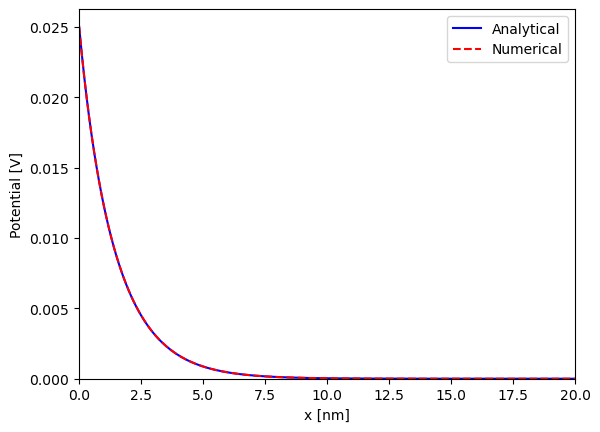

In [5]:
fig, ax = plt.subplots()

# potential in V
ax.plot(
    x.to("nm"), non_linear_pb.edl_status.phi.to("V"), color="blue", label="Analytical"
)
ax.plot(
    edl_obj.result.coordinate.to("nm"),
    edl_obj.result.solution.to("V"),
    color="red",
    linestyle="dashed",
    label="Numerical",
)
ax.legend()

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Potential [V]")

plt.show()

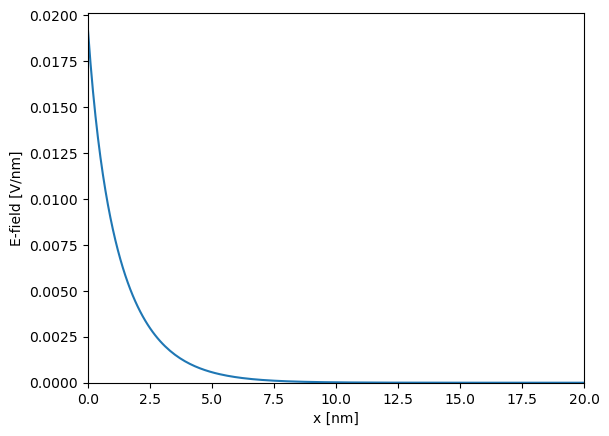

In [6]:
fig, ax = plt.subplots()

ax.plot(x.to("nm"), non_linear_pb.edl_status.efield.to("V/nm"))

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("E-field [V/nm]")

plt.show()

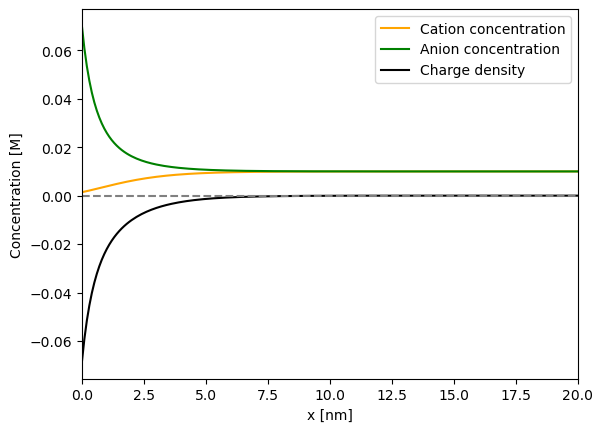

In [7]:
fig, ax = plt.subplots()

# ion conc in mol/L
c_cation = non_linear_pb.edl_status.ion_conc["Ca"]
c_anion = non_linear_pb.edl_status.ion_conc["SO4"]

ax.plot(x.to("nm"), c_cation, color="orange", label="Cation concentration")
ax.plot(x.to("nm"), c_anion, color="green", label="Anion concentration")
ax.plot(x.to("nm"), c_cation - c_anion, color="k", label="Charge density")

ax.axhline(0.0, color="gray", linestyle="dashed")

ax.set_xlim(0, 20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Concentration [M]")
ax.legend()

plt.show()